%% Importing librarires

In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import tree 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

%%

In [18]:
def plot_confusion_matrix(y,y_predict,ticks_labels=['did not land', 'landed']):
    """this function plots the confusion matrix
    comparing actual values : y, and predicted value : y_predict
    """
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, cmap='magma_r'); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(ticks_labels)
    ax.yaxis.set_ticklabels(ticks_labels)
    return ax

In [ ]:
def train_display_plot(method):
    method.fit(X_train, Y_train)

    # Display the best parameters after fitting
    print(f"Tuned hpyerparameters :(best parameters)\n{method.best_params_}")
    print(f"Accuracy for best hyperparameters:\n{100*method.best_score_:.2f}%")
    print(f'Accuracy on the test data:\n{100*method.score(X_test, Y_test):.2f}%')

    # Confusion Matrix
    y_pred = method.predict(X_test)
    fig, ax = plt.subplots(figsize=(6,4))
    ax = plot_confusion_matrix(Y_test, y_pred)
    ax.set_title(f'Confusion matrix for method {method.estimator}')


%% Reading datasets from online storage

In [20]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
# data features 
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

%% <br>
target variable

In [21]:
Y = data['Class']
# Standardize the X data
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(X)
# Split data into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
test_size=0.2, random_state=2)

%% Logistic Regression

/home/lugabo/Documents/GitHub/Capstone_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lugabo/Documents/GitHub/Capstone_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

Tuned hpyerparameters :(best parameters)
{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy for best hyperparameters:
84.64%
Accuracy on the test data:
83.33%


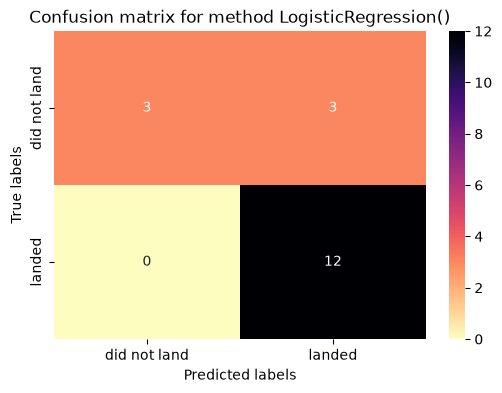

In [22]:
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg, 
param_grid={'C':[0.01,0.1,1], 'penalty':['l2',], 'solver':['lbfgs']}, cv = 10)
train_display_plot(logreg_cv)

%% Support Vector Machine

Tuned hpyerparameters :(best parameters)
{'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Accuracy for best hyperparameters:
84.82%
Accuracy on the test data:
83.33%


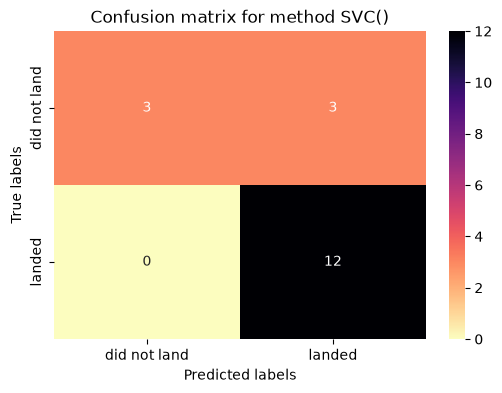

In [23]:
svm = SVC()
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm_cv = GridSearchCV(svm, param_grid=parameters, cv=10, )
train_display_plot(svm_cv)

%% Decision Tree classifier

Tuned hpyerparameters :(best parameters)
{'criterion': 'gini', 'max_depth': 12, 'max_features': 100, 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'best'}
Accuracy for best hyperparameters:
87.14%
Accuracy on the test data:
83.33%


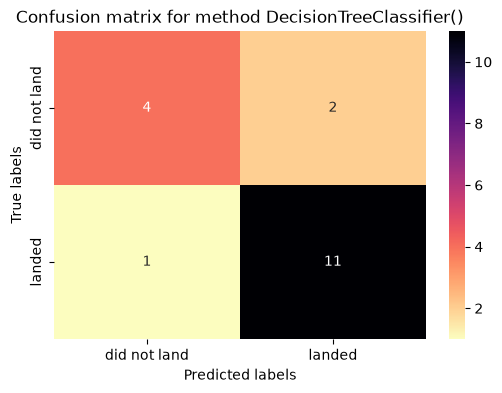

In [24]:
dtree = DecisionTreeClassifier()
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': [100, 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}
tree_cv = GridSearchCV(dtree, param_grid=parameters, cv = 10, error_score='raise' )
train_display_plot(tree_cv)

%% K-nearest neighbors

In [25]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

Tuned hpyerparameters :(best parameters)
{'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Accuracy for best hyperparameters:
84.82%
Accuracy on the test data:
83.33%


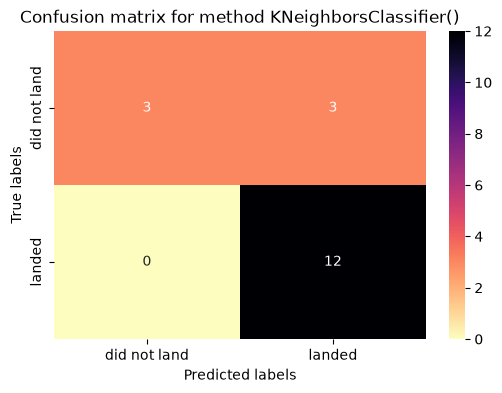

In [26]:
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, param_grid=parameters, cv=10)
train_display_plot(knn_cv)